In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

city = "Poltava"
mean_temp = 8.5
amplitude = 14
hum_base = 72

In [14]:
# Створення даних

months = []
temperatures = []
humidities = []
heating_days = []
heating_costs = []

for month in range(1, 13):

    temp = (
        mean_temp
        + amplitude * np.cos((month - 7) / 12 * 2 * np.pi)
        + np.random.normal(0, 1.0)
    )

    humidity = hum_base + np.random.normal(0, 5.0)

    if temp < 8:
        opal_days = 30
    elif temp < 12:
        opal_days = 15
    else:
        opal_days = 0

    cost = (
        200
        - 9.0 * temp
        + 0.6 * humidity
        + 2.5 * opal_days
        + np.random.normal(0, 15)
    )

    months.append(month)
    temperatures.append(temp)
    humidities.append(humidity)
    heating_days.append(opal_days)
    heating_costs.append(cost)

temperatures = np.array(temperatures)
humidities = np.array(humidities)
heating_days = np.array(heating_days)
y = np.array(heating_costs)

print("Дані для Полтави:")
for i in range(12):
    print(
        f"Місяць {months[i]}: "
        f"температура={temperatures[i]:.1f}, "
        f"вологість={humidities[i]:.1f}, "
        f"днів={heating_days[i]}, "
        f"витрати={y[i]:.1f}"
    )

Дані для Полтави:
Місяць 1: температура=-5.0, вологість=71.3, днів=30, витрати=372.5
Місяць 2: температура=-2.1, вологість=70.8, днів=30, витрати=332.9
Місяць 3: температура=3.1, вологість=75.8, днів=30, витрати=285.7
Місяць 4: температура=9.0, вологість=69.7, днів=15, витрати=190.9
Місяць 5: температура=15.7, вологість=62.4, днів=0, витрати=69.9
Місяць 6: температура=20.1, вологість=66.9, днів=0, витрати=64.3
Місяць 7: температура=21.6, вологість=64.9, днів=0, витрати=66.6
Місяць 8: температура=20.4, вологість=72.3, днів=0, витрати=38.4
Місяць 9: температура=15.0, вологість=72.6, днів=0, витрати=91.7
Місяць 10: температура=8.9, вологість=69.0, днів=15, витрати=194.6
Місяць 11: температура=0.9, вологість=81.3, днів=30, витрати=315.5
Місяць 12: температура=-4.7, вологість=76.1, днів=30, витрати=344.5


In [15]:
# Матриця X: constant + температура + вологість

X1 = np.column_stack([
    np.ones(12),
    temperatures,
    humidities
])

# OLS
beta1 = np.linalg.lstsq(X1, y, rcond=None)[0]

# Прогноз
fitted1 = X1 @ beta1

# Залишки
residuals1 = y - fitted1

# R²
ss_res = np.sum(residuals1 ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

r2_1 = 1 - ss_res / ss_tot

# Adjusted R²
n = len(y)
k = 2

adj_r2_1 = 1 - (1 - r2_1) * (n - 1) / (n - k - 1)

print("ЗАВДАННЯ 1")
print("=" * 50)

print("Intercept:", round(beta1[0], 4))
print("Температура:", round(beta1[1], 4))
print("Вологість:", round(beta1[2], 4))

print("R²:", round(r2_1, 4))
print("Adjusted R²:", round(adj_r2_1, 4))

ЗАВДАННЯ 1
Intercept: 222.5522
Температура: -12.2976
Вологість: 1.1275
R²: 0.9758
Adjusted R²: 0.9704


In [16]:
print("ЗАВДАННЯ 2")
print("=" * 50)

print(
    f"За незмінної вологості збільшення температури "
    f"на 1 °C змінює очікувані витрати на "
    f"{beta1[1]:.2f} умовних одиниць."
)

print(
    f"За незмінної температури збільшення вологості "
    f"на 1 % змінює очікувані витрати на "
    f"{beta1[2]:.2f} умовних одиниць."
)

print(
    "\nP-value тут не обчислюємо, оскільки для його "
    "розрахунку за стандартною процедурою потрібен "
    "додатковий статистичний пакет."
)

ЗАВДАННЯ 2
За незмінної вологості збільшення температури на 1 °C змінює очікувані витрати на -12.30 умовних одиниць.
За незмінної температури збільшення вологості на 1 % змінює очікувані витрати на 1.13 умовних одиниць.

P-value тут не обчислюємо, оскільки для його розрахунку за стандартною процедурою потрібен додатковий статистичний пакет.


In [17]:
def calculate_vif_simple(x, z):

    X = np.column_stack([
        np.ones(len(x)),
        z
    ])

    beta = np.linalg.lstsq(X, x, rcond=None)[0]

    predicted = X @ beta

    ss_res = np.sum((x - predicted) ** 2)
    ss_tot = np.sum((x - np.mean(x)) ** 2)

    r2 = 1 - ss_res / ss_tot

    return 1 / (1 - r2)


vif_temp = calculate_vif_simple(
    temperatures,
    humidities
)

vif_hum = calculate_vif_simple(
    humidities,
    temperatures
)

print("ЗАВДАННЯ 3")
print("=" * 50)

print("VIF температури:", round(vif_temp, 2))
print("VIF вологості:", round(vif_hum, 2))

ЗАВДАННЯ 3
VIF температури: 1.56
VIF вологості: 1.56


In [18]:
X2 = np.column_stack([
    np.ones(12),
    temperatures,
    humidities,
    heating_days
])

beta2 = np.linalg.lstsq(X2, y, rcond=None)[0]

fitted2 = X2 @ beta2

residuals2 = y - fitted2

ss_res2 = np.sum(residuals2 ** 2)

r2_2 = 1 - ss_res2 / ss_tot

k2 = 3

adj_r2_2 = 1 - (1 - r2_2) * (n - 1) / (n - k2 - 1)

print("ЗАВДАННЯ 4")
print("=" * 50)

print("Модель 1:")
print("R² =", round(r2_1, 4))
print("Adjusted R² =", round(adj_r2_1, 4))

print("\nМодель 2:")
print("R² =", round(r2_2, 4))
print("Adjusted R² =", round(adj_r2_2, 4))

print("\nКоефіцієнти моделі 2:")
print("Intercept:", round(beta2[0], 4))
print("Температура:", round(beta2[1], 4))
print("Вологість:", round(beta2[2], 4))
print("Опалювальні дні:", round(beta2[3], 4))

ЗАВДАННЯ 4
Модель 1:
R² = 0.9758
Adjusted R² = 0.9704

Модель 2:
R² = 0.9917
Adjusted R² = 0.9886

Коефіцієнти моделі 2:
Intercept: 239.1196
Температура: -6.7198
Вологість: -0.721
Опалювальні дні: 4.4701


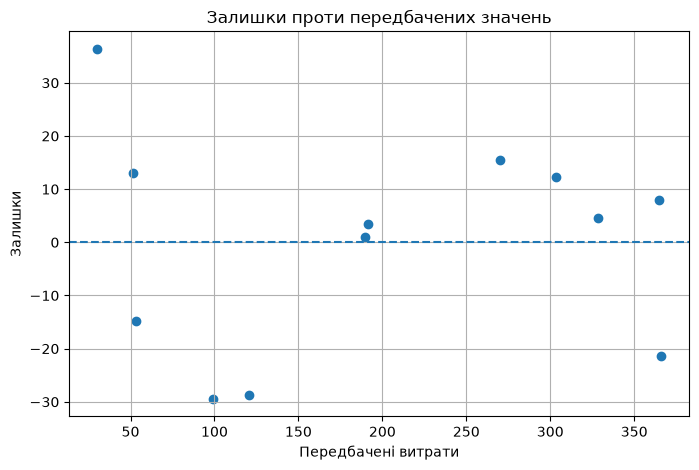

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    fitted1,
    residuals1
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Передбачені витрати")
plt.ylabel("Залишки")
plt.title("Залишки проти передбачених значень")

plt.grid(True)
plt.show()

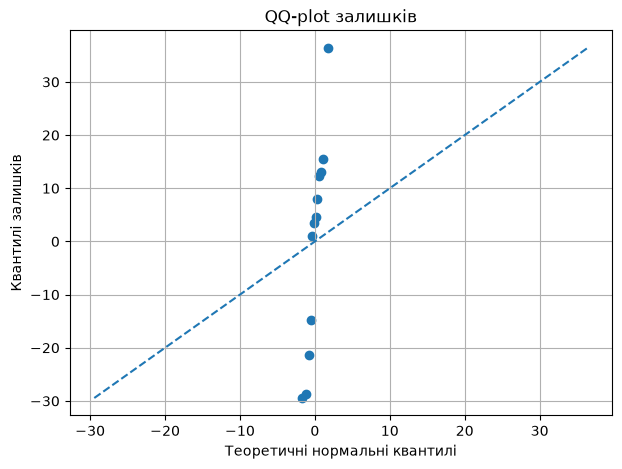

In [20]:
import statistics

sorted_residuals = np.sort(residuals1)

probabilities = (
    np.arange(1, len(y) + 1) - 0.5
) / len(y)

theoretical = np.array([
    statistics.NormalDist().inv_cdf(p)
    for p in probabilities
])

plt.figure(figsize=(7, 5))

plt.scatter(
    theoretical,
    sorted_residuals
)

min_value = min(
    theoretical.min(),
    sorted_residuals.min()
)

max_value = max(
    theoretical.max(),
    sorted_residuals.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Теоретичні нормальні квантилі")
plt.ylabel("Квантилі залишків")
plt.title("QQ-plot залишків")

plt.grid(True)
plt.show()

In [21]:
X_simple = np.column_stack([
    np.ones(12),
    temperatures
])

beta_simple = np.linalg.lstsq(
    X_simple,
    y,
    rcond=None
)[0]

fitted_simple = X_simple @ beta_simple

residuals_simple = y - fitted_simple

ss_res_simple = np.sum(
    residuals_simple ** 2
)

r2_simple = 1 - (
    ss_res_simple / ss_tot
)

print("ЗАВДАННЯ 6")
print("=" * 50)

print(
    "R² простої регресії:",
    round(r2_simple, 4)
)

print(
    "R² множинної регресії:",
    round(r2_1, 4)
)

print(
    "Adjusted R² множинної регресії:",
    round(adj_r2_1, 4)
)

ЗАВДАННЯ 6
R² простої регресії: 0.9744
R² множинної регресії: 0.9758
Adjusted R² множинної регресії: 0.9704
